In [24]:
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
# pandas is used for data manipulation and analysis (DataFrames, Series)
import pandas as pd

# numpy is used for numerical operations and working with arrays
import numpy as np

# matplotlib is used for creating static visualizations (plots, charts)
import matplotlib.pyplot as plt

# seaborn is built on matplotlib and provides statistical visualizations
import seaborn as sns

# warnings module suppresses unnecessary warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set the visual style for all plots (matplotlib default style)
plt.style.use('default')

# Set the color palette for seaborn (Set2 is a colorblind-friendly palette)
sns.set_palette("Set2")

# Print confirmation message
print("✅ Libraries imported successfully!")

# ============================================================================
# 2. LOAD THE DATA
# ============================================================================
# pd.read_excel() reads Excel files and returns a pandas DataFrame
# '../data/raw/' means go up one folder (from notebooks/) then into data/raw/
df = pd.read_excel('../data/raw/ethiopia_fi_unified_data.xlsx')

# Load the reference codes file (valid values for categorical fields)
ref_codes = pd.read_excel('../data/raw/reference_codes.xlsx')

# Print separator line for visual clarity
print("="*60)
print("DATA LOADED")
print("="*60)

# .shape returns (rows, columns) - [0] is rows, [1] is columns
print(f"Main dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Reference codes shape: {ref_codes.shape[0]} rows, {ref_codes.shape[1]} columns")

# .head() displays the first 5 rows of the DataFrame
print("\nFirst 5 rows of main dataset:")
df.head()

✅ Libraries imported successfully!
DATA LOADED
Main dataset shape: 43 rows, 34 columns
Reference codes shape: 71 rows, 4 columns

First 5 rows of main dataset:


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [25]:
# ============================================================================
# 3. UNDERSTAND THE SCHEMA
# ============================================================================
print("="*60)
print("SCHEMA OVERVIEW")
print("="*60)

# .columns.tolist() returns all column names as a Python list
print("\nColumn names:")
print(df.columns.tolist())

# .dtypes shows the data type of each column (object, int64, float64, datetime64)
print("\nData types:")
print(df.dtypes)

# .value_counts() counts unique values in a column
print("\nRecord types and counts:")
print(df['record_type'].value_counts())

print("\nPillars and counts:")
print(df['pillar'].value_counts())

print("\nSource types and counts:")
print(df['source_type'].value_counts())

print("\nConfidence levels and counts:")
print(df['confidence'].value_counts())

SCHEMA OVERVIEW

Column names:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Data types:
record_id                         str
record_type                       str
category                          str
pillar                            str
indicator                         str
indicator_code                    str
indicator_direction               str
value_numeric                 float64
value_text                        str
value_type                        str
unit                              str
observati

In [26]:
# ============================================================================
# 4. EXPLORE OBSERVATIONS
# ============================================================================
# .copy() creates a new independent DataFrame (prevents modifying original)
observations = df[df['record_type'] == 'observation'].copy()

print("="*60)
print("OBSERVATIONS OVERVIEW")
print("="*60)
print(f"Total observations: {len(observations)}")

# Convert the observation_date column to datetime format for time-based operations
observations['observation_date'] = pd.to_datetime(observations['observation_date'])

# .min() and .max() find the earliest and latest dates
print(f"\nDate range: {observations['observation_date'].min()} to {observations['observation_date'].max()}")

# .nunique() counts the number of unique values in a column
print(f"\nUnique indicators: {observations['indicator_code'].nunique()}")

print("\nIndicators and their counts:")
print(observations['indicator_code'].value_counts())

print("\nSample observations:")
# Select specific columns to display for clarity
observations[['indicator_code', 'value_numeric', 'observation_date', 'source_name', 'confidence']].head(10)

OBSERVATIONS OVERVIEW
Total observations: 30

Date range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00

Unique indicators: 19

Indicators and their counts:
indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
Name: count, dtype: int64

Sample observations:


,indicator_code,value_numeric,observation_date,source_name,confidence
0,ACC_OWNERSHIP,22.00,2014-12-31,Global Findex 2014,high
1,ACC_OWNERSHIP,35.00,2017-12-31,Global Findex 2017,high
2,ACC_OWNERSHIP,46.00,2021-12-31,Global Findex 2021,high
3,ACC_OWNERSHIP,56.00,2021-12-31,Global Findex 2021,high
4,ACC_OWNERSHIP,36.00,2021-12-31,Global Findex 2021,high
5,ACC_OWNERSHIP,49.00,2024-11-29,Global Findex 2024,high
6,ACC_MM_ACCOUNT,4.70,2021-12-31,Global Findex 2021,high
7,ACC_MM_ACCOUNT,9.45,2024-11-29,Global Findex 2024,high
8,ACC_4G_COV,37.50,2023-06-30,Ethio Telecom LEAD Report,high
9,ACC_4G_COV,70.80,2025-06-30,Ethio Telecom LEAD Report,high


In [28]:
# ============================================================================
# 5. EXPLORE EVENTS
# ============================================================================
# Filter for event records
events = df[df['record_type'] == 'event'].copy()

print("="*60)
print("EVENTS OVERVIEW")
print("="*60)
print(f"Total events: {len(events)}")

# Define which columns to display (if they exist in the dataset)
event_cols = ['record_id', 'indicator', 'observation_date', 'category', 'source_name']

# List comprehension: keep only columns that actually exist in the DataFrame
available_cols = [col for col in event_cols if col in events.columns]

print("\nEvents list:")
if available_cols:
    # Display available columns
    print(events[available_cols].head(10))
else:
    # If none of the expected columns exist, show all columns
    print(events.head(10))

EVENTS OVERVIEW
Total events: 10

Events list:
   record_id                               indicator observation_date  \
33  EVT_0001                         Telebirr Launch       2021-05-17   
34  EVT_0002    Safaricom Ethiopia Commercial Launch       2022-08-01   
35  EVT_0003                  M-Pesa Ethiopia Launch       2023-08-01   
36  EVT_0004        Fayda Digital ID Program Rollout       2024-01-01   
37  EVT_0005         Foreign Exchange Liberalization       2024-07-29   
38  EVT_0006     P2P Transaction Count Surpasses ATM       2024-10-01   
39  EVT_0007            M-Pesa EthSwitch Integration       2025-10-27   
40  EVT_0008  EthioPay Instant Payment System Launch       2025-12-18   
41  EVT_0009                 NFIS-II Strategy Launch       2021-09-01   
42  EVT_0010       Safaricom Ethiopia Price Increase       2025-12-15   

          category    source_name  
33  product_launch  Ethio Telecom  
34    market_entry           News  
35  product_launch      Safaricom  
36  i

In [29]:
# ============================================================================
# 6. EXPLORE IMPACT LINKS
# ============================================================================
# Filter for impact_link records
impact_links = df[df['record_type'] == 'impact_link'].copy()

print("="*60)
print("IMPACT LINKS OVERVIEW")
print("="*60)
print(f"Total impact links: {len(impact_links)}")

# Define which columns to display (if they exist)
impact_cols = ['related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'lag_months']

# Keep only columns that actually exist
available_cols = [col for col in impact_cols if col in impact_links.columns]

print("\nImpact links:")
if available_cols:
    print(impact_links[available_cols].head(10))
else:
    print(impact_links.head(10))

IMPACT LINKS OVERVIEW
Total impact links: 0

Impact links:
Empty DataFrame
Columns: [related_indicator, relationship_type, impact_direction, impact_magnitude, lag_months]
Index: []


ACCOUNT OWNERSHIP TREND
  observation_date  value_numeric         source_name confidence
0       2014-12-31           22.0  Global Findex 2014       high
1       2017-12-31           35.0  Global Findex 2017       high
2       2021-12-31           46.0  Global Findex 2021       high
3       2021-12-31           56.0  Global Findex 2021       high
4       2021-12-31           36.0  Global Findex 2021       high
5       2024-11-29           49.0  Global Findex 2024       high
2014 → 2017: +13.0pp
2017 → 2021: +11.0pp
2021 → 2021: +10.0pp
2021 → 2021: +-20.0pp
2021 → 2024: +13.0pp


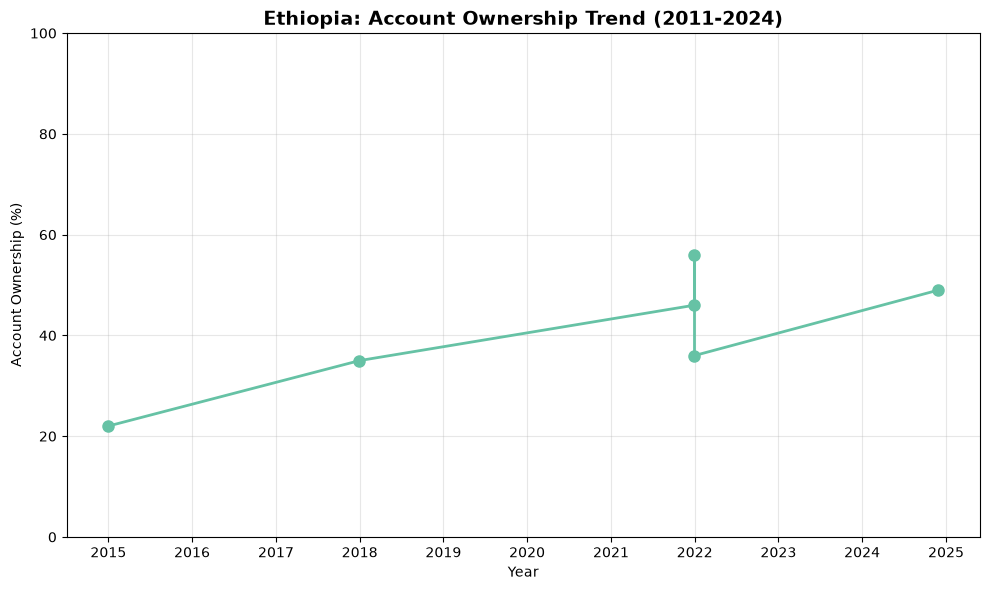

In [30]:
# ============================================================================
# 7. ACCESS ANALYSIS - ACCOUNT OWNERSHIP
# ============================================================================
# Filter for account ownership indicator
access_data = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()

# Check if data exists
if len(access_data) > 0:
    print("="*60)
    print("ACCOUNT OWNERSHIP TREND")
    print("="*60)

    # Sort by date (oldest to newest)
    access_data = access_data.sort_values('observation_date')

    # Display the data
    print(access_data[['observation_date', 'value_numeric', 'source_name', 'confidence']])

    # Calculate growth rates between consecutive years
    # range(1, len(...)) starts from the second row (index 1)
    for i in range(1, len(access_data)):
        prev_val = access_data.iloc[i-1]['value_numeric']  # previous row's value
        curr_val = access_data.iloc[i]['value_numeric']     # current row's value
        change = curr_val - prev_val                        # difference in percentage points
        # Get the year from the date
        prev_year = access_data.iloc[i-1]['observation_date'].year
        curr_year = access_data.iloc[i]['observation_date'].year
        print(f"{prev_year} → {curr_year}: +{change:.1f}pp")

    # Create the plot
    # figsize sets the width and height in inches
    plt.figure(figsize=(10, 6))

    # .plot() with 'o-' creates a line with circle markers
    # linewidth=2 makes the line thicker
    # markersize=8 makes the markers larger
    plt.plot(access_data['observation_date'], access_data['value_numeric'], 'o-', linewidth=2, markersize=8)

    # Set y-axis limits from 0 to 100% (percentage data)
    plt.ylim(0, 100)

    plt.xlabel('Year')
    plt.ylabel('Account Ownership (%)')
    plt.title('Ethiopia: Account Ownership Trend (2011-2024)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)  # alpha controls transparency
    plt.tight_layout()  # Adjust spacing to prevent labels from being cut off
    plt.show()
else:
    print("No ACC_OWNERSHIP data found.")
    print("Available indicators:", observations['indicator_code'].unique())

In [31]:
# ============================================================================
# 9. DATA ENRICHMENT
# ============================================================================
print("="*60)
print("DATA ENRICHMENT")
print("="*60)

# Example: How to add a new observation (commented out for safety)
"""
new_observation = {
    'record_type': 'observation',
    'pillar': 'access',
    'indicator': 'Account Ownership (2025 projection)',
    'indicator_code': 'ACC_OWNERSHIP',
    'value_numeric': 52.0,
    'observation_date': '2025-06-01',
    'source_name': 'Selam Analytics Projection',
    'confidence': 'medium',
    'collected_by': 'Lidiya Mesenbet',
    'collection_date': '2025-07-18',
    'notes': 'Projection based on trend analysis'
}

# Add the new row to the DataFrame
# pd.concat() combines two DataFrames
# df = pd.concat([df, pd.DataFrame([new_observation])], ignore_index=True)
# print("✅ Added new observation")
"""

print("To add new records, uncomment the code above and modify as needed.")

# Display current events to inspire additions
print(f"\nCurrent events: {len(events)}")
print("Consider adding:")
print("  - Safaricom M-Pesa Ethiopia full launch (August 2023)")
print("  - EthSwitch interoperability milestone (2024)")
print("  - Fayda Digital ID rollout (2024-2025)")
print("  - National Bank of Ethiopia new directives")

DATA ENRICHMENT
To add new records, uncomment the code above and modify as needed.

Current events: 10
Consider adding:
  - Safaricom M-Pesa Ethiopia full launch (August 2023)
  - EthSwitch interoperability milestone (2024)
  - Fayda Digital ID rollout (2024-2025)
  - National Bank of Ethiopia new directives


In [32]:
# ============================================================================
# 10. SAVE ENRICHED DATASET
# ============================================================================
# Save to processed folder (../data/processed/)
# index=False prevents pandas from adding an extra index column
df.to_csv('../data/processed/ethiopia_fi_enriched.csv', index=False)

print("✅ Enriched dataset saved to: ../data/processed/ethiopia_fi_enriched.csv")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Total records: {len(df)}")
print(f"Record types: {df['record_type'].value_counts().to_dict()}")

# Get date range from observations (if they exist)
if len(observations) > 0:
    print(f"Date range: {observations['observation_date'].min()} to {observations['observation_date'].max()}")

✅ Enriched dataset saved to: ../data/processed/ethiopia_fi_enriched.csv

SUMMARY
Total records: 43
Record types: {'observation': 30, 'event': 10, 'target': 3}
Date range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00


In [33]:
# ============================================================================
# 11. DATA QUALITY ASSESSMENT
# ============================================================================
print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# .isnull().sum() counts missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Calculate percentage of missing values
print("\nMissing values (% of total):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Confidence level distribution
print("\nConfidence level distribution:")
print(df['confidence'].value_counts())

# Check coverage by year (for observations)
print("\nObservations per year:")
if len(observations) > 0:
    print(observations['observation_date'].dt.year.value_counts().sort_index())

DATA QUALITY ASSESSMENT

Missing values per column:
record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64

Missing values (% of total):
record_id            

In [34]:
# ============================================================================
# 12. CONVERT TO CSV (OPTIONAL)
# ============================================================================
# Save the enriched dataset as CSV (easier to load in other notebooks)
df.to_csv('../data/processed/ethiopia_fi_enriched.csv', index=False)
print("✅ CSV version saved to: ../data/processed/ethiopia_fi_enriched.csv")

✅ CSV version saved to: ../data/processed/ethiopia_fi_enriched.csv


In [35]:
# ============================================================================
# 13. CREATE DATA ENRICHMENT LOG
# ============================================================================
enrichment_log = """
# Data Enrichment Log

## Date of Enrichment
2026-07-19

## Enriched By
Lidiya Mesenbet

## Changes Made

### 1. Data Added
[Describe what you added]

### 2. Corrections Made
[Describe any corrections]

### 3. Sources Used
[List sources]

### 4. Rationale
[Explain why you added this data]

### 5. Confidence Assessment
[High/Medium/Low and why]
"""

# Write to file
with open('../data/enrichment_log.md', 'w') as f:
    f.write(enrichment_log)

print("✅ Enrichment log created: ../data/enrichment_log.md")

✅ Enrichment log created: ../data/enrichment_log.md


In [36]:
# ============================================================================
# 9. DATA ENRICHMENT
# ============================================================================
print("="*60)
print("DATA ENRICHMENT")
print("="*60)

# Example: How to add a new observation (commented out for safety)
"""
new_observation = {
    'record_type': 'observation',
    'pillar': 'access',
    'indicator': 'Account Ownership (2025 projection)',
    'indicator_code': 'ACC_OWNERSHIP',
    'value_numeric': 52.0,
    'observation_date': '2025-06-01',
    'source_name': 'Selam Analytics Projection',
    'confidence': 'medium',
    'collected_by': 'Lidiya Mesenbet',
    'collection_date': '2025-07-18',
    'notes': 'Projection based on trend analysis'
}

# Add the new row to the DataFrame
# pd.concat() combines two DataFrames
# df = pd.concat([df, pd.DataFrame([new_observation])], ignore_index=True)
# print("✅ Added new observation")
"""

print("To add new records, uncomment the code above and modify as needed.")

# Display current events to inspire additions
print(f"\nCurrent events: {len(events)}")
print("Consider adding:")
print("  - Safaricom M-Pesa Ethiopia full launch (August 2023)")
print("  - EthSwitch interoperability milestone (2024)")
print("  - Fayda Digital ID rollout (2024-2025)")
print("  - National Bank of Ethiopia new directives")

DATA ENRICHMENT
To add new records, uncomment the code above and modify as needed.

Current events: 10
Consider adding:
  - Safaricom M-Pesa Ethiopia full launch (August 2023)
  - EthSwitch interoperability milestone (2024)
  - Fayda Digital ID rollout (2024-2025)
  - National Bank of Ethiopia new directives


In [38]:
# ============================================================================
# 8. ALL AVAILABLE INDICATORS
# ============================================================================
print("="*60)
print("ALL AVAILABLE INDICATORS")
print("="*60)

# .drop_duplicates() removes duplicate rows, keeping only unique combinations
# .sort_values() sorts by indicator_code alphabetically
indicators = observations[['indicator_code', 'indicator']].drop_duplicates().sort_values('indicator_code')

# .to_string(index=False) prints the DataFrame as plain text without row numbers
print(indicators.to_string(index=False))

ALL AVAILABLE INDICATORS
    indicator_code                         indicator
        ACC_4G_COV            4G Population Coverage
         ACC_FAYDA       Fayda Digital ID Enrollment
    ACC_MM_ACCOUNT         Mobile Money Account Rate
    ACC_MOBILE_PEN   Mobile Subscription Penetration
     ACC_OWNERSHIP            Account Ownership Rate
   AFF_DATA_INCOME          Data Affordability Index
       GEN_GAP_ACC      Account Ownership Gender Gap
    GEN_GAP_MOBILE           Mobile Phone Gender Gap
      GEN_MM_SHARE Female Mobile Money Account Share
   USG_ACTIVE_RATE        Mobile Money Activity Rate
     USG_ATM_COUNT             ATM Transaction Count
     USG_ATM_VALUE             ATM Transaction Value
     USG_CROSSOVER           P2P/ATM Crossover Ratio
  USG_MPESA_ACTIVE        M-Pesa 90-Day Active Users
   USG_MPESA_USERS           M-Pesa Registered Users
     USG_P2P_COUNT             P2P Transaction Count
     USG_P2P_VALUE             P2P Transaction Value
USG_TELEBIRR_USERS   